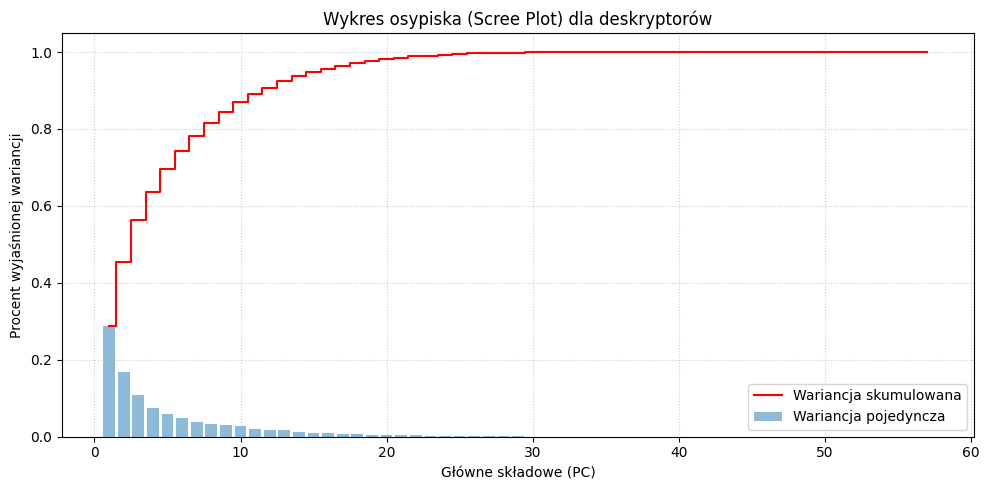

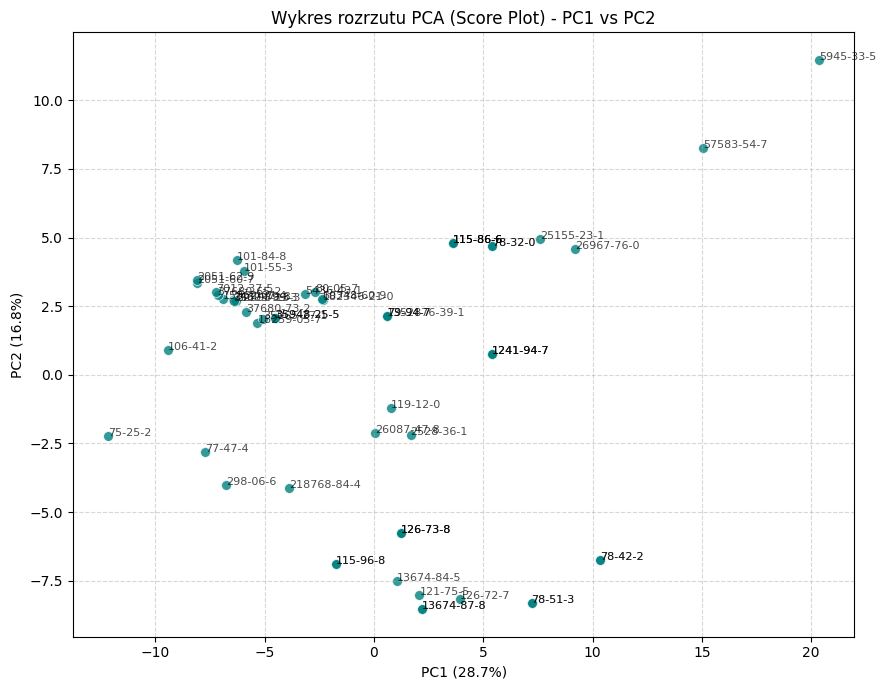

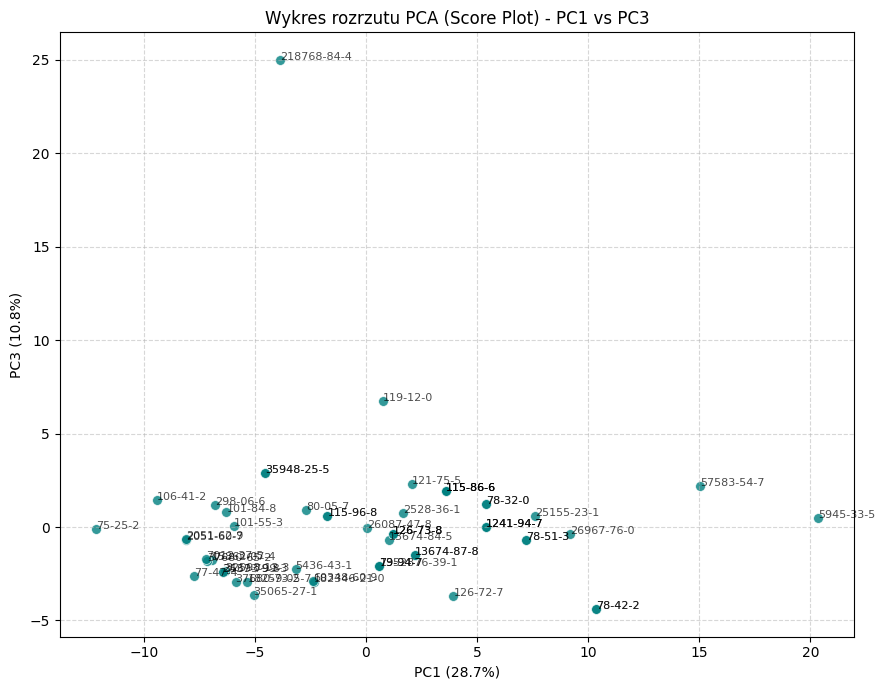

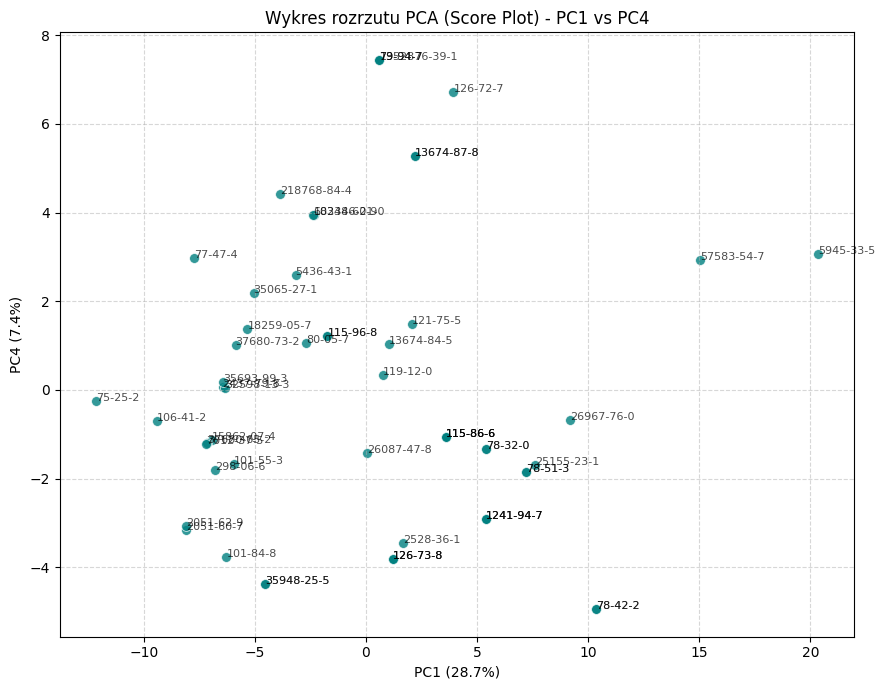

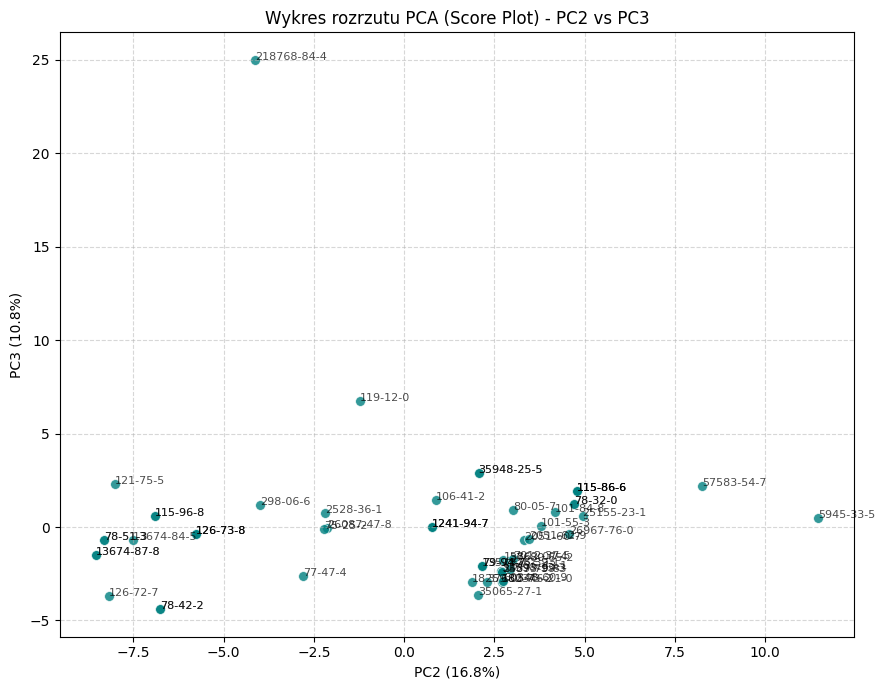

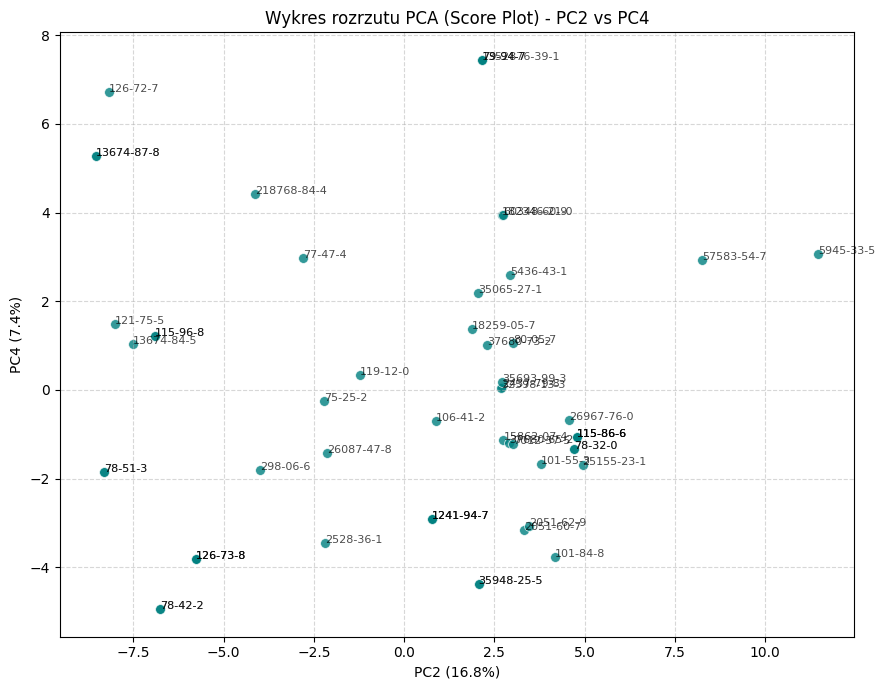

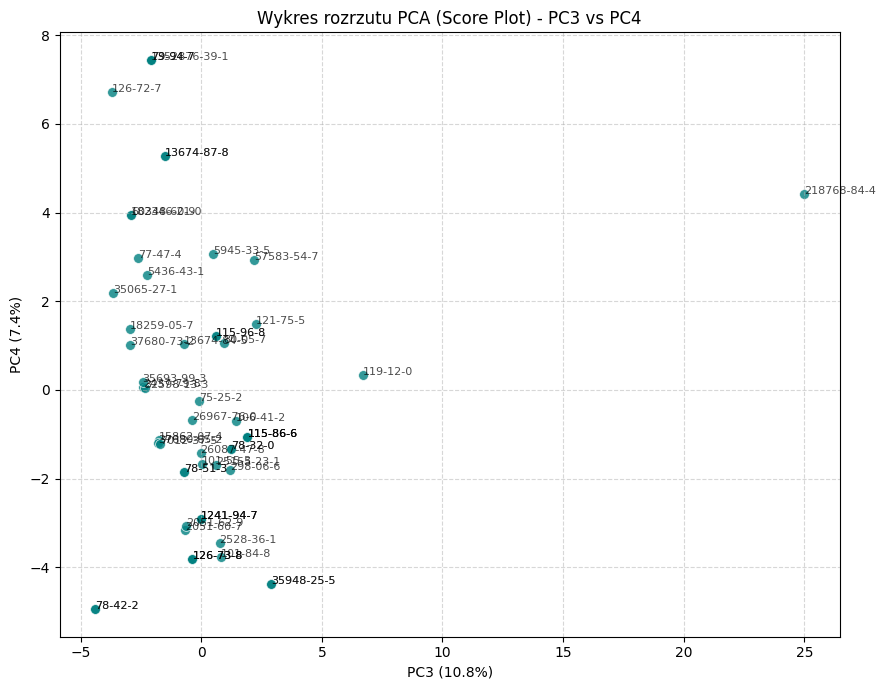

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from itertools import combinations

sciezka_pliku = './deskryptory_z_cas.xlsx'

df = pd.read_excel(sciezka_pliku)

df.set_index(df.columns[0], inplace=True)

X = df.select_dtypes(include=[np.number]).dropna()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='Wariancja pojedyncza')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Wariancja skumulowana', color='red')
plt.ylabel('Procent wyjaśnionej wariancji')
plt.xlabel('Główne składowe (PC)')
plt.title('Wykres osypiska (Scree Plot) dla deskryptorów')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
pc_columns = ["PC1", "PC2", "PC3", "PC4"]
pca_df = pd.DataFrame(data=X_pca[:, :4], columns=pc_columns, index=X.index)


for pc_x, pc_y in combinations(pc_columns, 2):

    idx_x = int(pc_x[-1]) - 1
    idx_y = int(pc_y[-1]) - 1

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        data=pca_df,
        x=pc_x,
        y=pc_y,
        alpha=0.8,
        color="teal",
        edgecolor="w",
        s=50,
    )

    plt.title(f"Wykres rozrzutu PCA (Score Plot) - {pc_x} vs {pc_y}")
    plt.xlabel(f"{pc_x} ({explained_variance[idx_x]*100:.1f}%)")
    plt.ylabel(f"{pc_y} ({explained_variance[idx_y]*100:.1f}%)")
    plt.grid(True, linestyle="--", alpha=0.5)

    for i, txt in enumerate(pca_df.index):
        plt.annotate(
            txt, (pca_df[pc_x].iloc[i], pca_df[pc_y].iloc[i]), fontsize=8, alpha=0.7
        )

    plt.tight_layout()
    plt.show()